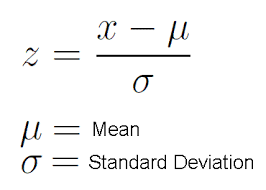

In [1]:
import pandas as pd
import sklearn 


In [2]:
car_data = pd.read_csv("..\\Datasets\\cars2.csv")

car_data.head()


,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1.0,790,99
1,Mitsubishi,Space Star,1.2,1160,95
2,Skoda,Citigo,1.0,929,95
3,Fiat,500,0.9,865,90
4,Mini,Cooper,1.5,1140,105


In [4]:
dataFrame = pd.DataFrame(car_data)
dataFrame.head()

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1.0,790,99
1,Mitsubishi,Space Star,1.2,1160,95
2,Skoda,Citigo,1.0,929,95
3,Fiat,500,0.9,865,90
4,Mini,Cooper,1.5,1140,105


In [5]:
print(type(car_data))
print(type(dataFrame))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [6]:
X = dataFrame[['Volume', 'Weight']]
y = dataFrame['CO2'] #or dataFrame.iloc[:,-1]
X.head()


,Volume,Weight
0,1.0,790
1,1.2,1160
2,1.0,929
3,0.9,865
4,1.5,1140


In [7]:
y.head()

0     99
1     95
2     95
3     90
4    105
Name: CO2, dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler

### z = (x-u)/s
```
x = xi, 
u - mean
s (sigma) = scale or S.D 
```



In [9]:
scale = StandardScaler()

scaledX = scale.fit_transform(X) 
print(scaledX)

[[-1.59336644 -2.10389253]
 [-1.07190106 -0.55407235]
 [-1.59336644 -1.52166278]
 [-1.85409913 -1.78973979]
 [-0.28970299 -0.63784641]
 [-1.59336644 -1.52166278]
 [-0.55043568 -0.76769621]
 [-0.28970299  0.3046118 ]
 [-0.28970299 -0.7551301 ]
 [-0.0289703  -0.59595938]
 [-1.33263375 -1.30803892]
 [-0.81116837 -1.26615189]
 [-1.59336644 -0.7551301 ]
 [-0.0289703  -0.16871166]
 [-0.0289703   0.14125238]
 [-0.0289703   0.15800719]
 [-0.0289703   0.3046118 ]
 [ 1.53542584 -0.05142797]
 [-0.0289703  -0.72580918]
 [ 1.01396046  0.14962979]
 [-0.0289703   1.2219378 ]
 [ 1.01396046  0.5685001 ]
 [ 1.27469315  0.3046118 ]
 [-0.0289703   0.51404696]
 [ 1.01396046  0.51404696]
 [-0.28970299  0.72348212]
 [ 1.01396046  0.8281997 ]
 [ 1.01396046  1.81254495]
 [-0.0289703   0.96642691]
 [ 1.01396046  1.72877089]
 [ 1.27469315  1.30990057]
 [ 1.01396046  1.90050772]
 [-0.0289703  -0.23991961]
 [-0.0289703   0.40932938]
 [-0.0289703   0.47215993]
 [ 2.31762392  0.4302729 ]]


Spliting into Train_Test_Split

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y)

In [12]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(27, 2)
(9, 2)
(27,)
(9,)


In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
from sklearn.metrics import r2_score, accuracy_score, mean_squared_error

In [16]:
y_pred = model.predict(X_train)
y_pred

array([102.71682163, 100.51150979, 100.63375535, 101.9309573 ,
       102.00517782, 107.60001554,  95.30034659, 103.4546609 ,
       110.57146542, 101.55985471,  95.30034659, 106.57402601,
       102.05267704,  99.61597182, 106.91072712,  94.69348469,
        96.40544837,  98.21398796, 107.69169971, 102.32825538,
       103.18834022, 105.86674812, 101.42451141, 102.34571903,
       107.42206476,  98.07375292, 102.6076738 ])

In [17]:
pd.DataFrame({"actual":y_train, "pred":y_pred})

,actual,pred
23,99,102.716822
8,98,100.511510
4,105,100.633755
32,104,101.930957
13,94,102.005178
27,114,107.600016
2,95,95.300347
20,94,103.454661
35,120,110.571465
9,99,101.559855


In [18]:
model.score(X_train, y_train)

0.34193002267396355

In [19]:
r2_score(y_train, y_pred)

0.34193002267396355

In [20]:
import math

In [21]:
mse = mean_squared_error(y_pred, y_train)
print(mse)

rms = math.sqrt(mse)
print(rms)

31.749845325804326
5.634700109660169


In [22]:
# Testing 

In [23]:
y_pred_test = model.predict(X_test)
y_pred_test

array([106.24658254,  96.09930865, 102.49852598, 102.6731625 ,
        94.13848793, 101.61608575, 107.95854622, 106.30333941,
       107.51269728])

In [24]:
r2_score(y_test, y_pred_test)

0.426709589712286

In [25]:
# Testing a values

In [28]:
# scale_input = scale.transform([[2,2000]])
scale_input = scale.transform([[1.0,790]])
print("scaled values: ",scale_input)

out_put = model.predict(scale_input)
print(out_put)

scaled values:  [[-1.59336644 -2.10389253]]
[94.69348469]


c:\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
